# RE1.3 · Cifras de la ficha del conjunto derivado

Composición por especie, geometría de cada clase (duración, banda, ancho de banda), una galería
con un ejemplo por clase y las facetas duración × ancho de banda. Todo va a
`figures/RE_1-3/` para `RE_1-3_ficha-conjunto.tex`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import reporte
from matplotlib.patches import Rectangle
from matplotlib.ticker import NullFormatter
from reporte import TEXT_WIDTH_IN, number, percent, scalar

from core.config import RAW_DIR, P
from data.annotations import load_annotations
from data.manifest import duration_of
from data.species import CALL_TYPES, VALID_PAIRS
from prepare_data import JOINED_LABELS, select_experiment
from utils.audio import hz_to_y, load_clip, mel_spectrogram, mel_to_db

OUT = reporte.out_dir("RE_1-3")
SCIENTIFIC = {
    "aa": "Aotus azarae",
    "ac": "Ateles chamek",
    "as": "Alouatta sara",
    "cc": "Cebus cuscinus",
    "lw": "Leontocebus weddelli",
    "pt": "Plecturocebus toppini",
    "sb": "Saimiri boliviensis",
    "sm": "Sapajus macrocephalus",
}
COLUMNS = 3
# Clases cuya nube duración × ancho de banda se parte en dos (se ve en la figura de formas)
SPLIT_SHAPES = ("ac/bc", "sm/fs")


def readable_name(label: str) -> str:
    species, code = label.split("/")
    names = CALL_TYPES[next(s for s in CALL_TYPES if s.name.lower() == species)]
    return names.get(code, code).replace("_", " ")


SPECIES_COLORS = {
    "aa": "#7c3aed",
    "ac": "#f59e0b",
    "as": "#dc2626",
    "lw": "#1e40af",
    "pt": "#0d9488",
    "sb": "#00b4d8",
    "sm": "#22c55e",
}

In [2]:
annotations = load_annotations()
experiment, labels = select_experiment(annotations)
annotations["label"] = (annotations["species"] + "/" + annotations["call_type"]).replace(
    JOINED_LABELS
)
annotations["in_vocabulary"] = (
    pd.Series(list(zip(annotations["species"], annotations["call_type"], strict=True)))
    .isin(VALID_PAIRS)
    .to_numpy()
)
# Una grabación dañada no se puede abrir: cuenta como 0 s (no entra al caché, RE1.2).
durations = pd.Series(
    {path: duration_of(path) or 0.0 for path in annotations["audio_path"].unique()}
)
print(
    f"{len(annotations)} anotaciones · {len(durations)} grabaciones · "
    f"{durations.sum() / 3600:.1f} h de audio anotado"
)

19031 anotaciones · 2664 grabaciones · 24.9 h de audio anotado


In [3]:
# Composición por especie: grabaciones, horas, anotaciones y qué parte entra al experimento.
annotations["hours"] = annotations["audio_path"].map(durations) / 3600
by_species = (
    pd.DataFrame(
        {
            "grabaciones": annotations.groupby("species")["audio_path"].nunique(),
            "horas": annotations.groupby("species").apply(
                lambda g: durations[g["audio_path"].unique()].sum() / 3600
            ),
            "anotaciones": annotations.groupby("species").size(),
            "pares": annotations[annotations["in_vocabulary"]]
            .groupby("species")["label"]
            .nunique(),
            "clases": experiment.groupby("species")["label"].nunique(),
            "en experimento": experiment.groupby("species").size(),
        }
    )
    .fillna(0)
    .astype({"clases": int, "en experimento": int, "pares": int})
)
by_species = by_species.sort_values("anotaciones", ascending=False)
reporte.write_rows(
    OUT / "especies.tex",
    [
        (
            f"\\textit{{{SCIENTIFIC[str(sp)]}}}",
            str(sp).upper(),
            number(row.grabaciones),
            number(row.horas, 1),
            number(row.anotaciones),
            number(row.pares),
            number(row.clases),
            number(row["en experimento"]),
        )
        for sp, row in by_species.iterrows()
    ]
    + [
        (
            "\\textbf{Total}",
            "",
            number(len(durations)),
            number(durations.sum() / 3600, 1),
            number(len(annotations)),
            number(by_species.pares.sum()),
            number(len(labels)),
            number(len(experiment)),
        )
    ],
)
by_species.round(1)

,grabaciones,horas,anotaciones,pares,clases,en experimento
species,,,,,,
lw,409,3.7,4144,8,5,3453
sm,571,5.2,3621,8,5,3395
as,773,7.2,3566,2,2,3309
ac,379,3.6,3085,6,4,3021
sb,256,2.8,2337,4,4,2324
pt,315,2.8,1155,5,2,1027
aa,82,0.8,1094,3,3,1087
cc,7,0.0,29,1,0,0


In [4]:
# Geometría por clase: duración (mediana y cuartiles), banda y ancho de banda medianos.
grouped = experiment.groupby("label")
geometry = pd.DataFrame(
    {
        "n": grouped.size(),
        "dur_med": grouped["duration_s"].median(),
        "dur_q1": grouped["duration_s"].quantile(0.25),
        "dur_q3": grouped["duration_s"].quantile(0.75),
        "low": grouped["low_freq_hz"].median(),
        "high": grouped["high_freq_hz"].median(),
        "bw": grouped["bandwidth_hz"].median(),
        "bw_cv": grouped["bandwidth_hz"].std() / grouped["bandwidth_hz"].mean(),
    }
).sort_values("dur_med", ascending=False)


def seconds(value: float) -> str:
    return number(value, 2) if value < 1 else number(value, 1)


reporte.write_rows(
    OUT / "geometria.tex",
    [
        (
            f"\\texttt{{{name}}}",
            number(r.n),
            f"{seconds(r.dur_med)} [{seconds(r.dur_q1)}--{seconds(r.dur_q3)}]",
            f"{number(r.low)}--{number(r.high)}",
            number(r.bw),
            number(r.bw_cv, 2),
        )
        for name, r in geometry.iterrows()
    ],
)
extremes = {
    "duración": (experiment["duration_s"].min(), experiment["duration_s"].max()),
    "ancho de banda": (experiment["bandwidth_hz"].min(), experiment["bandwidth_hz"].max()),
}
geometry.round(3)

,n,dur_med,dur_q1,dur_q3,low,high,bw,bw_cv
label,,,,,,,,
as/hc,1400,11.024,7.129,15.871,47.522,768.948,726.700,0.233
pt/dc,635,6.678,4.759,9.549,25.000,1474.273,1409.100,0.675
ac/chc,236,1.189,0.865,1.583,192.297,3362.744,3160.868,0.503
ac/sc,158,1.180,0.867,1.422,2640.291,10725.782,8134.951,0.345
ac/gc,140,1.012,0.657,1.922,197.538,1465.462,1275.916,0.547
lw/sqc,154,0.812,0.605,1.048,5033.828,12949.800,7753.000,0.480
sb/pcc,290,0.726,0.496,1.059,6535.596,11754.635,4955.498,0.339
sm/sc,168,0.589,0.370,0.822,3387.073,10677.968,6877.700,0.390
sm/pc,242,0.550,0.404,0.823,2805.884,4435.345,1541.894,0.424


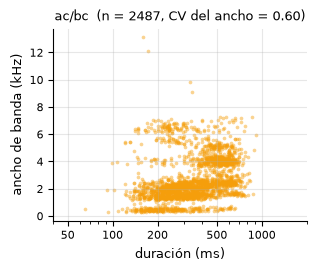

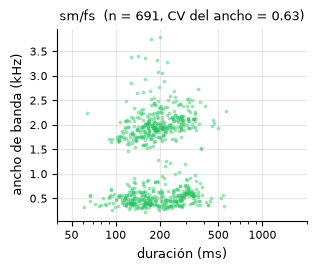

In [5]:
# Las dos etiquetas que esconden dos formas: la nube de duración × ancho de banda se parte en dos.
# Una imagen por clase, del ancho de media página, para que el documento las coloque por separado.
for name in SPLIT_SHAPES:
    subset = experiment.loc[experiment["label"] == name]
    fig, ax = plt.subplots(figsize=(TEXT_WIDTH_IN / 2, 2.6), constrained_layout=True)
    ax.scatter(
        subset["duration_s"] * 1000,
        subset["bandwidth_hz"] / 1000,
        s=7,
        color=SPECIES_COLORS[name.split("/")[0]],
        alpha=0.45,
        linewidths=0,
    )
    ax.set(
        xscale="log",
        xlim=(40, 2000),
        xlabel="duración (ms)",
        ylabel="ancho de banda (kHz)",
        title=f"{name}  (n = {len(subset)}, CV del ancho = {scalar(geometry, name, 'bw_cv'):.2f})",
    )
    ax.set_xticks([50, 100, 200, 500, 1000], ["50", "100", "200", "500", "1000"])
    ax.xaxis.set_minor_formatter(NullFormatter())
    reporte.save_figure(fig, OUT / f"formas_{name.replace('/', '_')}")
    plt.show()

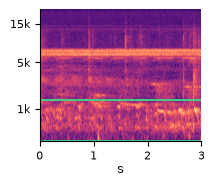

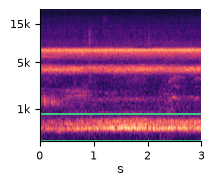

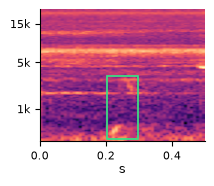

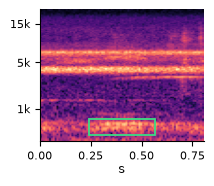

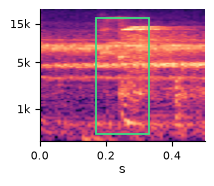

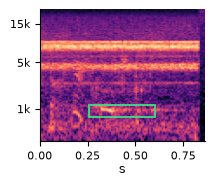

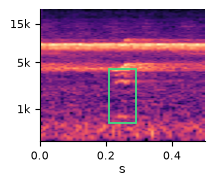

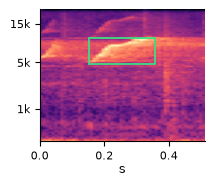

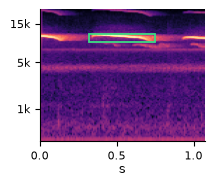

1640

In [6]:
# Galería: la clase más anotada de cada especie más las dos siguientes en volumen; de cada una, la
# anotación de duración más cercana a la mediana, en su contexto.
def median_example(name: str) -> pd.Series:
    subset = experiment.loc[experiment["label"] == name]
    return subset.loc[(subset["duration_s"] - subset["duration_s"].median()).abs().idxmin()]


by_size = experiment["label"].value_counts()
per_species = by_size.groupby(by_size.index.str.split("/").str[0]).idxmax().tolist()
chosen = (
    per_species
    + [c for c in by_size.index if c not in per_species][: COLUMNS * COLUMNS - len(per_species)]
)
chosen = geometry.loc[chosen].sort_values("low").index.tolist()

to_mel = mel_spectrogram()
frames_per_s = P.n_frames / P.clip_len_s
# Una imagen por clase (un tercio del ancho del texto) y el bloque de subfiguras que las
# coloca en una cuadrícula, con la clase y su nombre legible en cada subtítulo.
subfigures: list[str] = []
for name in chosen:
    fig, ax = plt.subplots(figsize=(TEXT_WIDTH_IN / 3, 1.75), constrained_layout=True)
    row = median_example(name)
    span = min(max(row["duration_s"] * 2.5, 0.5), P.clip_len_s)
    start = max(row["begin_time_s"] - (span - row["duration_s"]) / 2, 0.0)
    mel = mel_to_db(to_mel(load_clip(row["audio_path"], start)))[:, : int(span * frames_per_s)]
    ax.imshow(mel.numpy(), origin="lower", aspect="auto", cmap="magma", extent=(0, span, 0, 1))
    y0, y1 = hz_to_y(np.array([row["low_freq_hz"], row["high_freq_hz"]]), P)
    ax.add_patch(
        Rectangle(
            (row["begin_time_s"] - start, y0),
            row["duration_s"],
            y1 - y0,
            fill=False,
            edgecolor="#3ddc84",
            linewidth=1.3,
        )
    )
    ax.set_yticks(hz_to_y(np.array([1000.0, 5000.0, 15000.0]), P).tolist(), ["1k", "5k", "15k"])
    ax.set_xlabel("s", labelpad=1)
    ax.grid(False)
    stem = f"galeria_{name.replace('/', '_')}"
    reporte.save_figure(fig, OUT / stem)
    plt.show()
    subfigures.append(
        "\\begin{subfigure}[t]{0.32\\textwidth}\n"
        f"    \\includegraphics[width=\\linewidth]{{figures/RE_1-3/{stem}}}\n"
        f"    \\caption{{\\code{{{name}}}, {readable_name(name)}, {seconds(row['duration_s'])}\\,s}}\n"
        "\\end{subfigure}"
    )
# Tres por fila: `\\hfill` entre vecinas y un salto de línea al cerrar cada fila.
glue = [
    "\\\\[1.5ex]\n" if (i + 1) % COLUMNS == 0 else "\\hfill\n" for i in range(len(subfigures) - 1)
]
body = "".join(part for pair in zip(subfigures, [*glue, "\n"], strict=True) for part in pair)
(OUT / "galeria.tex").write_text("% generado por el cuaderno homónimo; no editar\n" + body)

In [7]:
counts = annotations.loc[annotations["in_vocabulary"], "label"].value_counts()
review = annotations.loc[~annotations["in_vocabulary"]]
# Las grabaciones se llaman AAAAMMDD_HHMMSS.wav (a veces AAMMDD_HHMM): de ahí la fecha y la hora.
names = pd.Series([Path(p).stem for p in durations.index]).str.extract(r"^(\d{6}|\d{8})_(\d{2})")
dates = pd.to_datetime(
    names[0].where(names[0].str.len() == 8, "20" + names[0]), format="%Y%m%d", errors="coerce"
)
hours_of_day = names[1].dropna().astype(int).value_counts().sort_index()
reporte.write_data(
    OUT / "horas", hours_of_day.rename_axis("hora").rename("grabaciones").reset_index()
)
months = dates.dt.to_period("M").value_counts().sort_index()
reporte.write_data(
    OUT / "meses", months.rename_axis("mes").rename("grabaciones").reset_index().astype(str)
)
print(
    f"{dates.isna().sum()} grabaciones sin fecha en el nombre · horas del día: {hours_of_day.to_dict()}"
)
reporte.write_macros(
    OUT / "valores.tex",
    {
        "n_recordings": number(len(durations)),
        "hours": number(durations.sum() / 3600, 1),
        "median_recording_s": number(durations.median()),
        "n_annotations": number(len(annotations)),
        "n_species": number(annotations["species"].nunique()),
        "n_vocab_pairs": number(len(counts)),
        "n_review": number(len(review)),
        "n_review_pairs": number(review["label"].nunique()),
        "n_classes": number(len(labels)),
        "n_experiment": number(len(experiment)),
        "pct_experiment": percent(len(experiment) / int(counts.sum())),
        "n_species_experiment": number(experiment["species"].nunique()),
        "dur_min_ms": number(extremes["duración"][0] * 1000),
        "dur_max_s": number(extremes["duración"][1], 1),
        "dur_ratio": number(extremes["duración"][1] / extremes["duración"][0]),
        "bw_min": number(extremes["ancho de banda"][0]),
        "bw_max": number(extremes["ancho de banda"][1]),
        "bw_ratio": number(extremes["ancho de banda"][1] / extremes["ancho de banda"][0]),
        "top_ten_share": percent(counts.head(10).sum() / counts.sum(), 0),
        "largest_pair": f"\\texttt{{{counts.index[0]}}}",
        "largest_pair_n": number(counts.iloc[0]),
        "split_shapes": " y ".join(f"\\texttt{{{c}}}" for c in SPLIT_SHAPES),
        "split_shapes_cv": " y ".join(
            number(scalar(geometry, c, "bw_cv"), 2) for c in SPLIT_SHAPES
        ),
        "first_date": dates.min().strftime("%d/%m/%Y"),
        "last_date": dates.max().strftime("%d/%m/%Y"),
        "first_hour": number(int(hours_of_day.index.min())),
        "last_hour": number(int(hours_of_day.index.max())),
        "pct_short_recordings": percent((durations <= 60).mean(), 0),
        "longest_class": f"\\texttt{{{geometry.index[0]}}}",
        "longest_class_s": number(geometry["dur_med"].iloc[0], 1),
        "shortest_class": f"\\texttt{{{geometry.index[-1]}}}",
        "shortest_class_ms": number(geometry["dur_med"].iloc[-1] * 1000),
    },
)
sorted(OUT.iterdir())

4 grabaciones sin fecha en el nombre · horas del día: {0: 2, 4: 5, 5: 309, 6: 476, 7: 383, 8: 228, 9: 272, 10: 238, 11: 140, 12: 114, 13: 7, 14: 35, 15: 92, 16: 221, 17: 84, 19: 24, 20: 15, 21: 5, 23: 10}


[PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_1-3/especies.tex'),
 PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_1-3/formas_ac_bc.png'),
 PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_1-3/formas_sm_fs.png'),
 PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_1-3/galeria.tex'),
 PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_1-3/galeria_aa_gc.png'),
 PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_1-3/galeria_ac_bc.png'),
 PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_1-3/galeria_as_bc.png'),
 PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_1-3/galeria_as_hc.png'),
 PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_1-3/galeria_lw_cs.png'),
 PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_1-3/galeria_pt_dc.png'),
 PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_1-3/